In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

In [30]:
df = pd.read_csv('tickets.csv')
df

,subject,body,type,queue,priority
0,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...",Incident,Technical Support,high
1,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Request,Returns and Exchanges,medium
2,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this mes...",Request,Billing and Payments,low
3,Question About Marketing Agency Software Compa...,"Dear Support Team,\n\nI hope this message reac...",Problem,Sales and Pre-Sales,medium
4,Feature Query,"Dear Customer Support,\n\nI hope this message ...",Request,Technical Support,high
...,...,...,...,...,...
13724,Problem with Billing Adjustment,An unexpected billing discrepancy has been not...,Incident,Billing and Payments,high
13725,Urgent: Incident Involving Data Breach in Medi...,"A data breach has occurred, which might be rel...",Problem,Product Support,medium
13726,Performance Problem with Data Analytics Tool,The data analytics tool experiences sluggish p...,Incident,Technical Support,high
13727,Update Request for SaaS Platform Integration F...,Requesting an update on the integration featur...,Change,IT Support,high


In [43]:
df['text'] = df['subject'] + " " + df['body']
df

,subject,body,type,queue,priority,text,text_length
0,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...",Incident,Technical Support,high,"Account Disruption Dear Customer Support Team,...",562
1,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Request,Returns and Exchanges,medium,Query About Smart Home System Integration Feat...,584
2,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this mes...",Request,Billing and Payments,low,Inquiry Regarding Invoice Details Dear Custome...,638
3,Question About Marketing Agency Software Compa...,"Dear Support Team,\n\nI hope this message reac...",Problem,Sales and Pre-Sales,medium,Question About Marketing Agency Software Compa...,731
4,Feature Query,"Dear Customer Support,\n\nI hope this message ...",Request,Technical Support,high,"Feature Query Dear Customer Support,\n\nI hope...",659
...,...,...,...,...,...,...,...
13724,Problem with Billing Adjustment,An unexpected billing discrepancy has been not...,Incident,Billing and Payments,high,Problem with Billing Adjustment An unexpected ...,154
13725,Urgent: Incident Involving Data Breach in Medi...,"A data breach has occurred, which might be rel...",Problem,Product Support,medium,Urgent: Incident Involving Data Breach in Medi...,140
13726,Performance Problem with Data Analytics Tool,The data analytics tool experiences sluggish p...,Incident,Technical Support,high,Performance Problem with Data Analytics Tool T...,119
13727,Update Request for SaaS Platform Integration F...,Requesting an update on the integration featur...,Change,IT Support,high,Update Request for SaaS Platform Integration F...,340


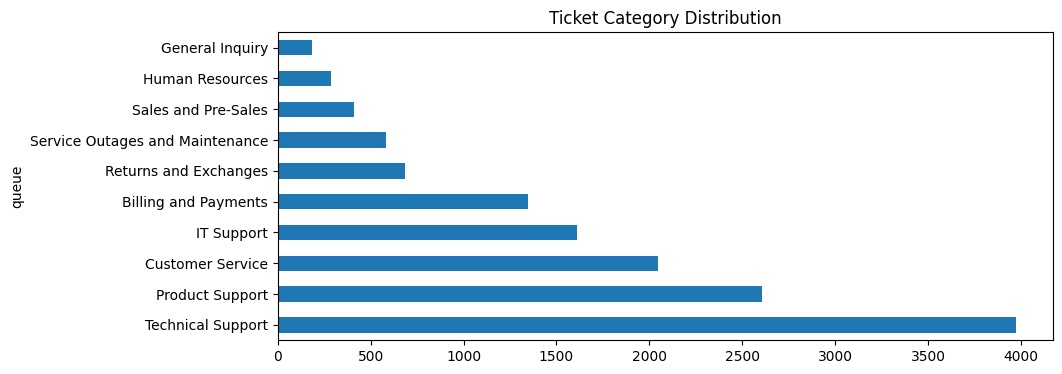

In [ ]:
df['queue'].value_counts().plot(kind='barh', figsize=(10, 4), title='Ticket Category Distribution')
#understanding class imbalance
plt.show()


In [ ]:
df['text_length'] = df['text'].str.len()
#added a new column of text length

print("\nAvg text length by category:\n", df.groupby('queue')['text_length'].mean()) 
#understanding avg text length


Avg text length by category:
 queue
Billing and Payments               395.358043
Customer Service                   400.197066
General Inquiry                    425.481283
Human Resources                    392.578947
IT Support                         403.002486
Product Support                    400.331926
Returns and Exchanges              398.606414
Sales and Pre-Sales                400.109756
Service Outages and Maintenance    401.335628
Technical Support                  404.704357
Name: text_length, dtype: float64


In [82]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    """
    Clean and normalize a ticket string.
    
    Each step removes a specific type of noise:
    - Lowercase: 'Login' and 'login' are the same concept
    - Remove URLs/emails: They're usually noise in tickets
    - Remove punctuation/numbers: Usually unhelpful for topic classification
    - Remove stopwords: 'the', 'is', 'at' add length but no meaning
    - Lemmatize: Reduces 'running', 'ran', 'runs' → 'run' (same concept)
    """
    
    # Convert to lowercase
    text = text.lower()

    # Fix escaped newlines
    text = text.replace('\\n', ' ')
    
    # Remove URLs (e.g., "visit http://support.example.com")
    text = re.sub(r'http\S+|www\S+', '', text)
    
    # Remove email addresses
    text = re.sub(r'\S+@\S+', '', text)
    
    # Remove special characters and digits
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Normalize whitespace (CRITICAL)
    text = re.sub(r'\s+', ' ', text).strip()
    
    # Tokenize — split into individual words
    tokens = text.split()
    
    # Remove stopwords AND lemmatize in one pass (efficient)
    tokens = [
        lemmatizer.lemmatize(word) 
        for word in tokens 
        if word not in stop_words and len(word) > 2  # also drop very short words
    ]
    
    return ' '.join(tokens)

# Apply to entire dataset
df['clean_text'] = df['text'].apply(preprocess_text)

# Quick sanity check — see what preprocessing did
print("Original:", df['text'].iloc[0])
print("Cleaned: ", df['clean_text'].iloc[0])

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\tammi\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\tammi\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\tammi\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Original: Account Disruption Dear Customer Support Team,\n\nI am writing to report a significant problem with the centralized account management portal, which currently appears to be offline. This outage is blocking access to account settings, leading to substantial inconvenience. I have attempted to log in multiple times using different browsers and devices, but the issue persists.\n\nCould you please provide an update on the outage status and an estimated time for resolution? Also, are there any alternative ways to access and manage my account during this downtime?
Cleaned:  account disruption dear customer support team writing report significant problem centralized account management portal currently appears offline outage blocking access account setting leading substantial inconvenience attempted log multiple time using different browser device issue persists could please provide update outage status estimated time resolution also alternative way access manage account downtime


In [83]:
df


,subject,body,type,queue,priority,text,text_length,clean_text
0,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...",Incident,Technical Support,high,"Account Disruption Dear Customer Support Team,...",562,account disruption dear customer support team ...
1,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Request,Returns and Exchanges,medium,Query About Smart Home System Integration Feat...,584,query smart home system integration feature de...
2,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this mes...",Request,Billing and Payments,low,Inquiry Regarding Invoice Details Dear Custome...,638,inquiry regarding invoice detail dear customer...
3,Question About Marketing Agency Software Compa...,"Dear Support Team,\n\nI hope this message reac...",Problem,Sales and Pre-Sales,medium,Question About Marketing Agency Software Compa...,731,question marketing agency software compatibili...
4,Feature Query,"Dear Customer Support,\n\nI hope this message ...",Request,Technical Support,high,"Feature Query Dear Customer Support,\n\nI hope...",659,feature query dear customer support hope messa...
...,...,...,...,...,...,...,...,...
13724,Problem with Billing Adjustment,An unexpected billing discrepancy has been not...,Incident,Billing and Payments,high,Problem with Billing Adjustment An unexpected ...,154,problem billing adjustment unexpected billing ...
13725,Urgent: Incident Involving Data Breach in Medi...,"A data breach has occurred, which might be rel...",Problem,Product Support,medium,Urgent: Incident Involving Data Breach in Medi...,140,urgent incident involving data breach medical ...
13726,Performance Problem with Data Analytics Tool,The data analytics tool experiences sluggish p...,Incident,Technical Support,high,Performance Problem with Data Analytics Tool T...,119,performance problem data analytics tool data a...
13727,Update Request for SaaS Platform Integration F...,Requesting an update on the integration featur...,Change,IT Support,high,Update Request for SaaS Platform Integration F...,340,update request saas platform integration featu...


In [91]:
from sklearn.model_selection import train_test_split

X = df['clean_text']
y = df['queue']

# Encode labels to integers — sklearn needs numbers, not strings
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# CRITICAL: Use stratify=y to maintain class proportions in both splits.
# Without this, your test set might accidentally have no examples of a rare class,
# giving you falsely optimistic evaluation results.
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,        # 80% train, 20% test
    random_state=42,      # reproducibility
    stratify=y_encoded    # <-- ensures proportional class representation
)

f"Train size: {len(X_train)}, Test size: {len(X_test)}"


'Train size: 10983, Test size: 2746'

In [92]:
from sklearn.feature_extraction.text import TfidfVectorizer

# We define the vectorizer here but DON'T fit it yet.
# It will be fit INSIDE the pipeline to prevent data leakage (explained below).
tfidf = TfidfVectorizer(
    max_features=50000,     # Keep only the top 50k most frequent terms
    ngram_range=(1, 2),     # Use single words AND two-word phrases ("login failed" > "login" + "failed")
    min_df=2,               # Ignore terms appearing in fewer than 2 documents (likely typos)
    max_df=0.95,            # Ignore terms appearing in >95% of documents (too common to be useful)
    sublinear_tf=True       # Apply log normalization to term frequency — handles outliers better
)